# Extraction Demo

In [1]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import warnings
import logging
from copy import deepcopy
warnings.filterwarnings("ignore")
logging.disable(logging.WARNING)

## Instantiate instrument
PyReduce defines instruments as subclasses of `pyreduce.instruments.Instrument` which live as packages in `pyreduce.instruments`. It contains methods to load, parse, and categorize raw FITS files based on the header keyword
information in the instrument config. Most methods can be used directly, or overriden if needed. We have created an instrument package for ZSHOOTER that is installed as the `ZSHOOTER` package, and overriden some
methods to load it correctly.

In [2]:
from zsdrp.ZSHOOTER import ZSHOOTER
zs = ZSHOOTER()

## Load files

In [3]:
rawdir = "../../zs-scopesim/dev_notebooks/sims_old/"  # path to your rawdir
outdir = rawdir+"/reduced"

files = {}
for chan in zs.config.channels:
    files[chan] = {}
    files[chan]['bias'] = sorted(glob.glob(f'{rawdir}/bias_{chan}*.fits'))
    files[chan]['flat'] = sorted(glob.glob(f'{rawdir}/flat_{chan}*.fits'))
    files[chan]['arcs'] = sorted(glob.glob(f'{rawdir}/arcs_{chan}*.fits'))
    files[chan]['star'] = sorted(glob.glob(f'{rawdir}/star_{chan}.fits'))
    files[chan]['sn'] = sorted(glob.glob(f'{rawdir}/sn_{chan}*.fits'))

In [16]:
# files

## Load reduction settings (input params for steps)

For the next steps, we need to set parameter/kwarg values for each step, tuned for the instrument data.

There are a set of default settings for each step stored in `pyreduce.defaults.settings.json`. Inside instrument package, `settings.json` inherits from the defaults and
contains entries that override specific parameters for that instrument. There can be multiple settings files, inheriting from each other for different channels.

In [17]:
from zsdrp.utils import load_zshooter_settings
settings_cfg = load_zshooter_settings() # returns a nested dict of per channel settings

Loading settings for channel: B
Loading settings for channel: G
Loading settings for channel: R
Loading settings for channel: YJ
Loading settings for channel: H
Loading settings for channel: K


In [18]:
settings_cfg['G']['flat']

{'bias_scaling': 'exposure_time',
 'norm_scaling': 'none',
 'plot': False,
 'plot_title': 'Flat'}

## Reduction steps

Let's reduce the data of one channel step-by-step using core algorithms from pyreduce. Some are imported directly, others have been put in convenience wrappers in `zsdrp.steps` and are imported from there.

In [19]:
channel = 'B'
chanfiles = files[channel]

### Master combine and load mask

Bad pixel masks or other type of masks should be created and saved in instrument package directory

For combining bias images, two core methods are available:
- `combine_bias`: if all images are biases
- `combine_polynomial`: if images are biases and darks

Preproc of other image types is handled by `combine_calibrate`. It corrects them by the provided master bias, and normalized flat, and returns combined image.

In [20]:
from pyreduce.combine_frames import combine_bias, combine_calibrate
from zsdrp.steps import MaskWrapper as mask_wrapper

# load mask
mask = mask_wrapper.run(zs, channel)
# create master bias
bias, bhead = combine_bias(files=chanfiles['bias'], instrument=zs, channel=channel)
# create master arc
arc, ahead = combine_calibrate(chanfiles['arcs'], instrument=zs, channel=channel, bias=bias, bhead=bhead, mask=mask)
# create master flat
flat, fhead = combine_calibrate(files=chanfiles['flat'], instrument=zs, channel=channel, bias=bias, bhead=bhead, mask=mask, **settings_cfg[channel].get('flat'))

### Trace orders

The pyreduce core functions for this and next steps are wrapped in `zsdrp.steps` functions to map settings keys to function
kwargs correctly.

Loading settings for channel: B
Loading settings for channel: G
Loading settings for channel: R
Loading settings for channel: YJ
Loading settings for channel: H
Loading settings for channel: K
Tracing parameters: {'degree': 4, 'max_error': None, 'degree_before_merge': 2, 'regularization': 0, 'closing_shape': [2, 2], 'opening_shape': [1, 1], 'auto_merge_threshold': 0.9, 'merge_min_threshold': 0.1, 'sigma': 5, 'filter_x': 0, 'filter_y': None, 'filter_type': 'gaussian', 'min_cluster': 20000, 'min_width': 0.5, 'noise': 0, 'noise_relative': 0.001, 'border_width': 40, 'manual': False, 'plot': True, 'plot_title': 'Order Tracing', 'order_centers': None}


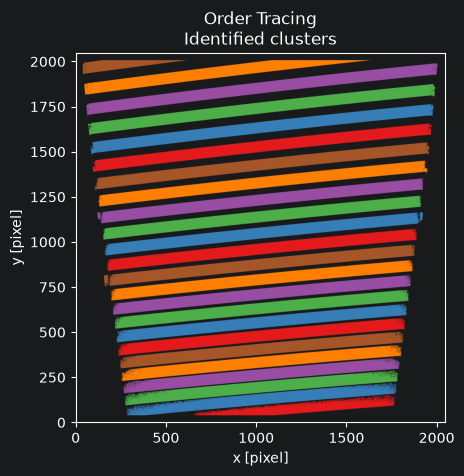

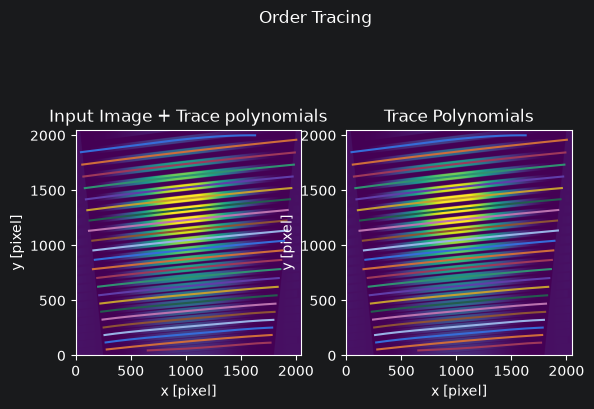

In [21]:
from zsdrp.steps import TraceWrapper as trace_wrapper

# reload settings if needed
settings_cfg = load_zshooter_settings()
cfg = settings_cfg[channel].get('trace')

traces = trace_wrapper.run(flat, cfg)
trace_wrapper.save(traces, f"{outdir}/trace_{channel}.fits")

### Slit curvature

Loading settings for channel: B
Loading settings for channel: G
Loading settings for channel: R
Loading settings for channel: YJ
Loading settings for channel: H
Loading settings for channel: K
Curvature parameters: {'mode': '2D', 'fit_degree': [1, 1], 'curve_degree': 1, 'curve_height': 0.9, 'extraction_height': 1, 'sigma_cutoff': 3, 'peak_threshold': 10, 'peak_width': 1, 'window_width': 9, 'peak_function': 'gaussian', 'plot': True, 'plot_title': 'Slit Curvature'}


Trace: 100%|██████████| 23/23 [17:59<00:00, 46.92s/it]


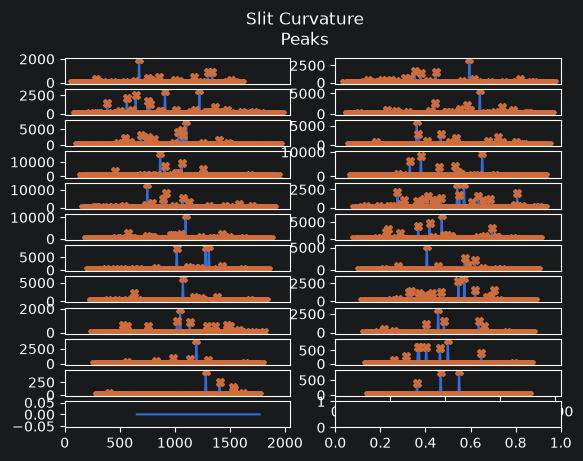

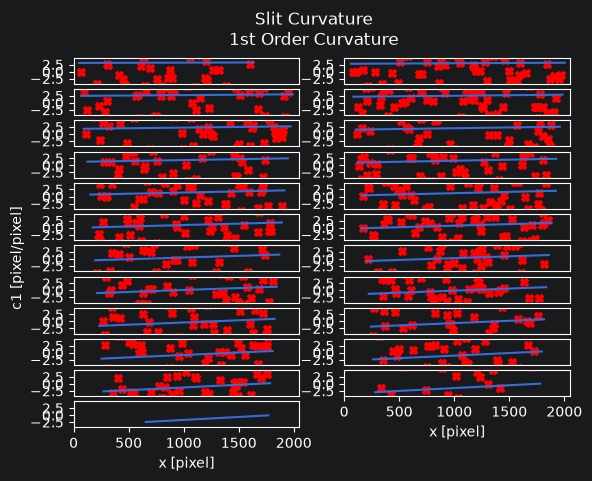

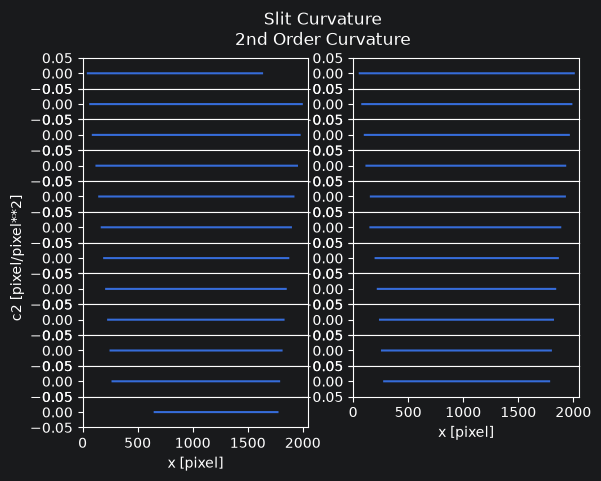

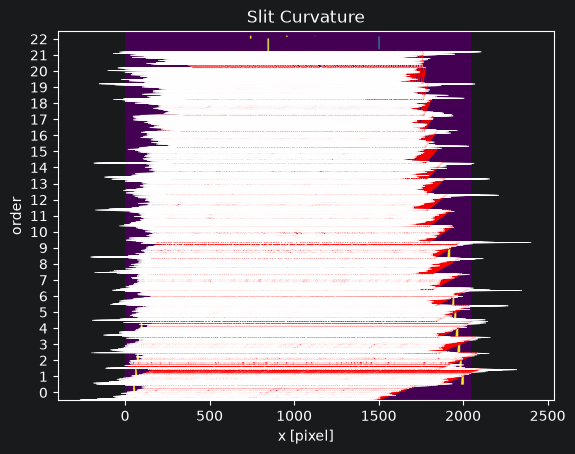

In [10]:
from zsdrp.steps import CurvatureWrapper as curvature_wrapper

settings_cfg = load_zshooter_settings()
cfg = settings_cfg[channel].get('curvature')

traces_with_curv = curvature_wrapper.run(arc, deepcopy(traces), step_cfg=cfg)

### Normalize flat field

Loading settings for channel: B
Loading settings for channel: G
Loading settings for channel: R
Loading settings for channel: YJ
Loading settings for channel: H
Loading settings for channel: K
Normflat parameters: {'extraction_method': 'normalize', 'lambda_sf': 0.9, 'lambda_sp': 0, 'osample': 8, 'maxiter': 3, 'swath_width': 50, 'extraction_height': 0.9, 'threshold': 100, 'threshold_lower': 0, 'reject_threshold': 6, 'plot': True, 'plot_title': 'Normalized Flat', 'gain': 1.0, 'readnoise': 0, 'dark': 0, 'scatter': None}


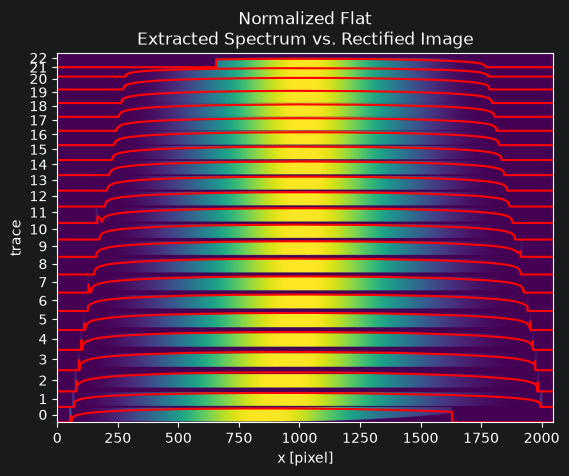

In [22]:
from zsdrp.steps import NormflatWrapper as normflat_wrapper

settings_cfg = load_zshooter_settings()
cfg = settings_cfg[channel].get('norm_flat')

norm, blaze, slitfunc, slitfunc_meta = normflat_wrapper.run(flat, fhead, traces, cfg)


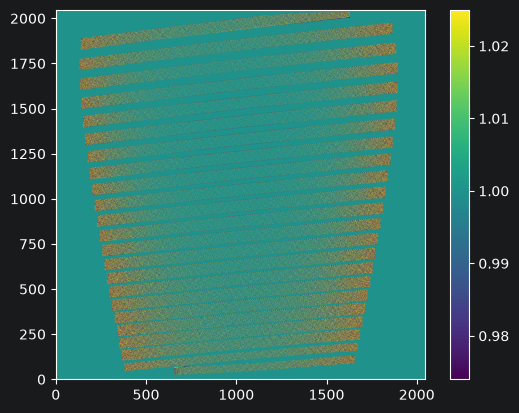

4.129702e-07 12.284762


In [25]:
vmin, vmax = np.percentile(norm, [5, 95])
plt.imshow(norm, origin='lower', vmin=vmin, vmax=vmax, cmap='viridis')
plt.colorbar()
plt.show()
print(norm.min(), norm.max())

### Extract science spectra

**NOTE** There is some issue in the norm_flat step above, it is not giving a smooth norm image, and if that is used below for science extraction it results in weird narrow artifacts. Setting norm=None for now.

Loading settings for channel: B
Loading settings for channel: G
Loading settings for channel: R
Loading settings for channel: YJ
Loading settings for channel: H
Loading settings for channel: K
Science extraction parameters: {'extraction_type': 'optimal', 'extraction_height': 1, 'osample': 10, 'swath_width': 1000, 'maxiter': 5, 'lambda_sf': 2, 'lambda_sp': 0, 'reject_threshold': 6, 'n_jobs': 1, 'plot': True, 'plot_title': 'Science Data', 'gain': 1.0, 'readnoise': 0, 'dark': 0, 'scatter': None}


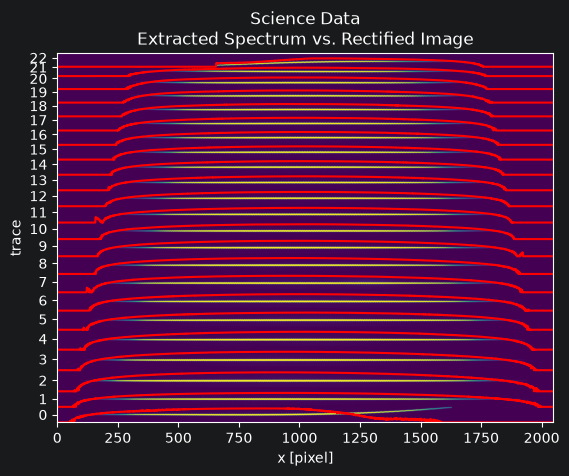

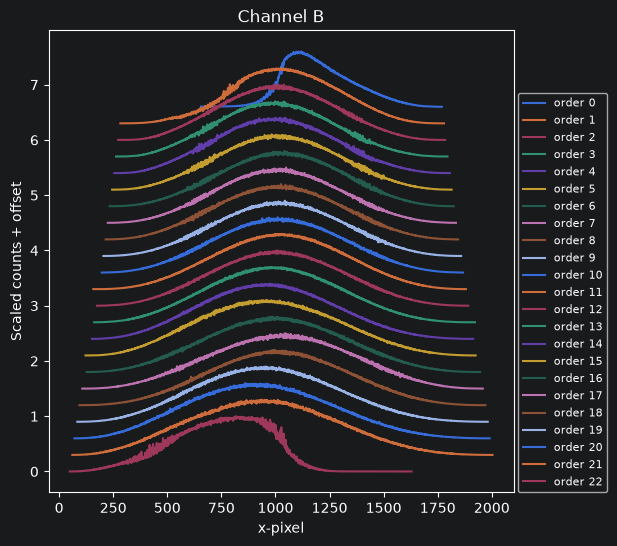

In [26]:
from zsdrp.steps import ScienceWrapper as sci_wrapper
from zsdrp.utils import plot_spectra_object

settings_cfg = load_zshooter_settings()
cfg = settings_cfg[channel].get('science')

spec = sci_wrapper.run(chanfiles['star'], traces, instrument=zs, channel=channel, bias=bias, bhead=bhead, norm=None, step_cfg=cfg)
ax = plot_spectra_object(spec, title=f'Channel {channel}', xlabel='x-pixel', ylabel='Scaled counts + offset')

## All together (testing pipe.py)

Loading settings for channel: B
Loading settings for channel: G
Loading settings for channel: R
Loading settings for channel: YJ
Loading settings for channel: H
Loading settings for channel: K
Running reduction for channel B...
Tracing parameters: {'degree': 4, 'max_error': None, 'degree_before_merge': 2, 'regularization': 0, 'closing_shape': [2, 2], 'opening_shape': [1, 1], 'auto_merge_threshold': 0.9, 'merge_min_threshold': 0.1, 'sigma': 5, 'filter_x': 0, 'filter_y': None, 'filter_type': 'gaussian', 'min_cluster': 20000, 'min_width': 0.5, 'noise': 0, 'noise_relative': 0.001, 'border_width': 40, 'manual': False, 'plot': True, 'plot_title': 'Order Tracing', 'order_centers': None}


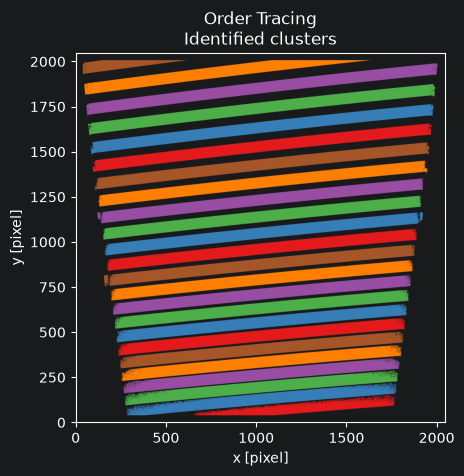

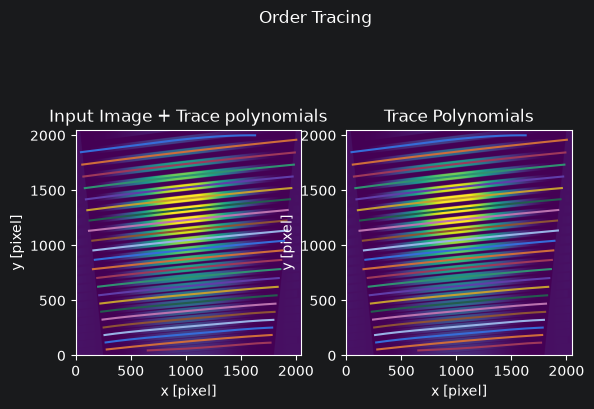

Running science reduction for object star ...
Science extraction parameters: {'extraction_type': 'optimal', 'extraction_height': 1, 'osample': 10, 'swath_width': 1000, 'maxiter': 5, 'lambda_sf': 2, 'lambda_sp': 0, 'reject_threshold': 6, 'n_jobs': 1, 'plot': True, 'plot_title': 'Science Data', 'gain': 1.0, 'readnoise': 0, 'dark': 0, 'scatter': None}


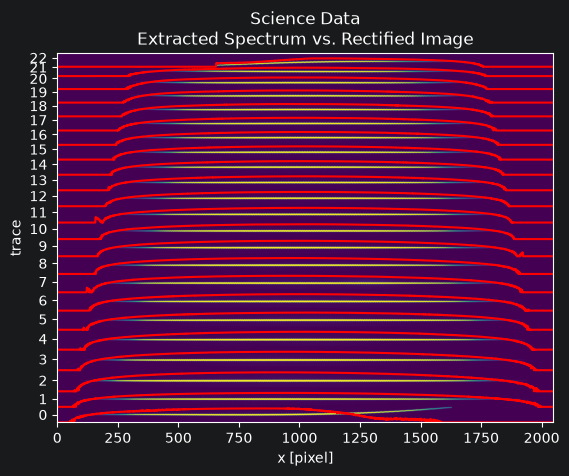

Running science reduction for object sn ...
Science extraction parameters: {'extraction_type': 'optimal', 'extraction_height': 1, 'osample': 10, 'swath_width': 1000, 'maxiter': 5, 'lambda_sf': 2, 'lambda_sp': 0, 'reject_threshold': 6, 'n_jobs': 1, 'plot': True, 'plot_title': 'Science Data', 'gain': 1.0, 'readnoise': 0, 'dark': 0, 'scatter': None}


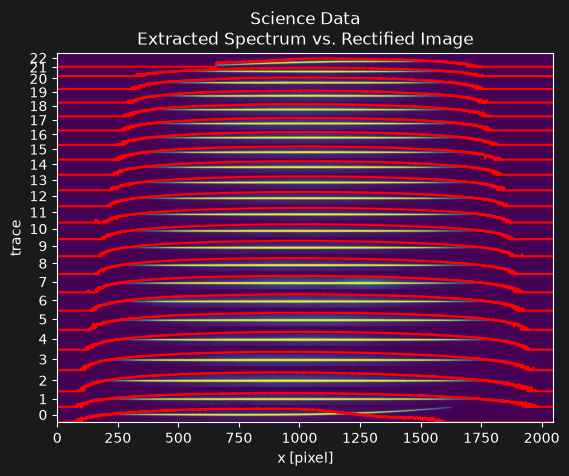

In [4]:
from zsdrp.pipe import run_reduction

results = run_reduction(files, bias_key='bias', flat_key='flat', arc_key='arcs',
                        zshooter_instrument=zs, channels='B', disable_steps=['curvature', 'norm_flat'])

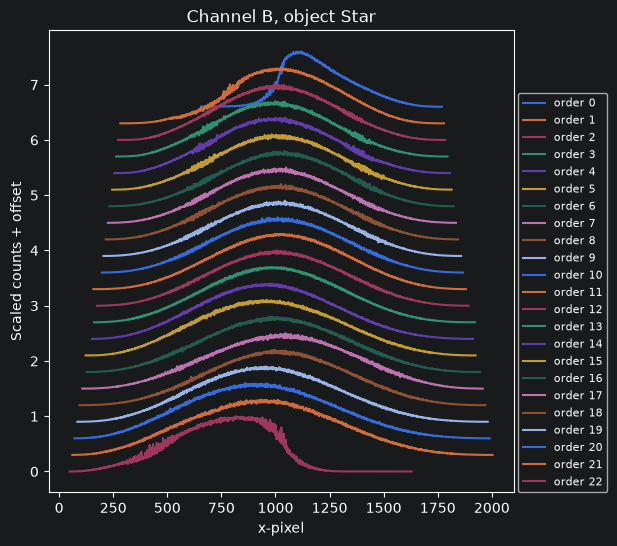

In [6]:
from zsdrp.utils import plot_spectra_object

ax = plot_spectra_object(results['B']['spectra']['star'], title=f'Channel B, object Star',
                         xlabel='x-pixel', ylabel='Scaled counts + offset')

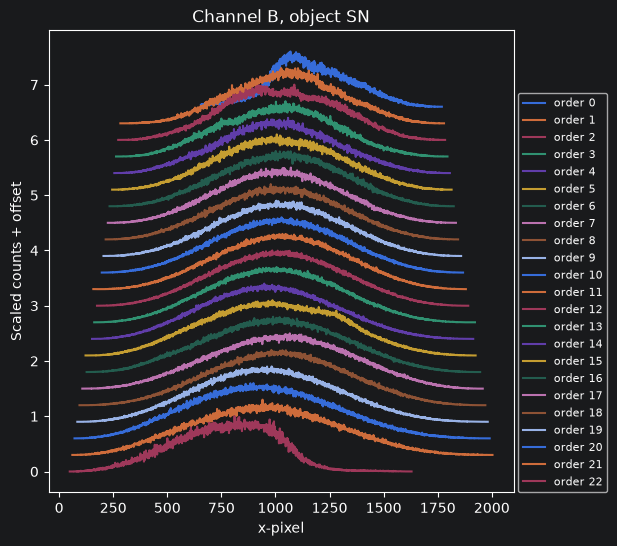

In [7]:
ax = plot_spectra_object(results['B']['spectra']['sn'], title=f'Channel B, object SN',
                         xlabel='x-pixel', ylabel='Scaled counts + offset')